In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from math import sqrt


import os

<!-- import glob

# Get a list of all .pt files in the directory
all_files = glob.glob(os.path.join(data_dir, '*.pt'))

print(f"Found {len(all_files)} processed cases.")

# Example of looping through the first 5 files
for file in all_files[:5]:
    data = torch.load(file, weights_only=False)
    print(f"Case {data['caseid']} has {data['features'].shape[0]} seconds of data.") -->

# iTransformer

#### Embed.py

In [3]:
class DataEmbedding_inverted(nn.Module):
    def __init__(self, c_in, d_model, embed_type='fixed', freq='h', dropout=0.1):
        super(DataEmbedding_inverted, self).__init__()
        self.value_embedding = nn.Linear(c_in, d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, x_mark):
        x = x.permute(0, 2, 1)
        # x: [Batch Variate Time]
        if x_mark is None:
            x = self.value_embedding(x)
        else:
            # the potential to take covariates (e.g. timestamps) as tokens
            x = self.value_embedding(torch.cat([x, x_mark.permute(0, 2, 1)], 1)) 
        # x: [Batch Variate d_model]
        return self.dropout(x)

#### Transformer_Encoder.py

In [5]:
class EncoderLayer(nn.Module):
    def __init__(self, attention, d_model, d_ff=None, dropout=0.1, activation="relu"):
        super(EncoderLayer, self).__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = attention
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = F.relu if activation == "relu" else F.gelu

    def forward(self, x, attn_mask=None, tau=None, delta=None):
        new_x, attn = self.attention(
            x, x, x,
            attn_mask=attn_mask,
            tau=tau, delta=delta
        )
        x = x + self.dropout(new_x)

        y = x = self.norm1(x)
        y = self.dropout(self.activation(self.conv1(y.transpose(-1, 1))))
        y = self.dropout(self.conv2(y).transpose(-1, 1))

        return self.norm2(x + y), attn


class Encoder(nn.Module):
    def __init__(self, attn_layers, conv_layers=None, norm_layer=None):
        super(Encoder, self).__init__()
        self.attn_layers = nn.ModuleList(attn_layers)
        self.conv_layers = nn.ModuleList(conv_layers) if conv_layers is not None else None
        self.norm = norm_layer

    def forward(self, x, attn_mask=None, tau=None, delta=None):
        # x [B, L, D]
        attns = []
        if self.conv_layers is not None:
            for i, (attn_layer, conv_layer) in enumerate(zip(self.attn_layers, self.conv_layers)):
                delta = delta if i == 0 else None
                x, attn = attn_layer(x, attn_mask=attn_mask, tau=tau, delta=delta)
                x = conv_layer(x)
                attns.append(attn)
            x, attn = self.attn_layers[-1](x, tau=tau, delta=None)
            attns.append(attn)
        else:
            for attn_layer in self.attn_layers:
                x, attn = attn_layer(x, attn_mask=attn_mask, tau=tau, delta=delta)
                attns.append(attn)

        if self.norm is not None:
            x = self.norm(x)

        return x, attns


#### masking.py

In [6]:
class TriangularCausalMask():
    def __init__(self, B, L, device="cpu"):
        mask_shape = [B, 1, L, L]
        with torch.no_grad():
            self._mask = torch.triu(torch.ones(mask_shape, dtype=torch.bool), diagonal=1).to(device)

    @property
    def mask(self):
        return self._mask

#### SelfAttention.py

In [8]:
class FullAttention(nn.Module):
    def __init__(self, mask_flag=True, factor=5, scale=None, attention_dropout=0.1, output_attention=False):
        super(FullAttention, self).__init__()
        self.scale = scale
        self.mask_flag = mask_flag
        self.output_attention = output_attention
        self.dropout = nn.Dropout(attention_dropout)

    def forward(self, queries, keys, values, attn_mask, tau=None, delta=None):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        scale = self.scale or 1. / sqrt(E)

        scores = torch.einsum("blhe,bshe->bhls", queries, keys)

        if self.mask_flag:
            if attn_mask is None:
                attn_mask = TriangularCausalMask(B, L, device=queries.device)

            scores.masked_fill_(attn_mask.mask, -np.inf)

        A = self.dropout(torch.softmax(scale * scores, dim=-1))
        V = torch.einsum("bhls,bshd->blhd", A, values)

        if self.output_attention:
            return (V.contiguous(), A)
        else:
            return (V.contiguous(), None)


class AttentionLayer(nn.Module):
    def __init__(self, attention, d_model, n_heads, d_keys=None,
                 d_values=None):
        super(AttentionLayer, self).__init__()

        d_keys = d_keys or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)

        self.inner_attention = attention
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.out_projection = nn.Linear(d_values * n_heads, d_model)
        self.n_heads = n_heads

    def forward(self, queries, keys, values, attn_mask, tau=None, delta=None):
        B, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads

        queries = self.query_projection(queries).view(B, L, H, -1)
        keys = self.key_projection(keys).view(B, S, H, -1)
        values = self.value_projection(values).view(B, S, H, -1)

        out, attn = self.inner_attention(
            queries,
            keys,
            values,
            attn_mask,
            tau=tau,
            delta=delta
        )
        out = out.view(B, L, -1)

        return self.out_projection(out), attn


#### iTransformer.py

In [9]:
class Model(nn.Module):
    """
    Paper link: https://arxiv.org/abs/2310.06625
    """

    def __init__(self, configs):
        super(Model, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.output_attention = configs.output_attention
        self.use_norm = configs.use_norm
        # Embedding
        self.enc_embedding = DataEmbedding_inverted(configs.seq_len, configs.d_model, configs.embed, configs.freq,
                                                    configs.dropout)
        self.class_strategy = configs.class_strategy
        # Encoder-only architecture
        self.encoder = Encoder(
            [
                EncoderLayer(
                    AttentionLayer(
                        FullAttention(False, configs.factor, attention_dropout=configs.dropout,
                                      output_attention=configs.output_attention), configs.d_model, configs.n_heads),
                    configs.d_model,
                    configs.d_ff,
                    dropout=configs.dropout,
                    activation=configs.activation
                ) for l in range(configs.e_layers)
            ],
            norm_layer=torch.nn.LayerNorm(configs.d_model)
        )
        self.projector = nn.Linear(configs.d_model, configs.pred_len, bias=True)

    def forecast(self, x_enc, x_mark_enc, x_dec, x_mark_dec):
        if self.use_norm:
            # Normalization from Non-stationary Transformer
            means = x_enc.mean(1, keepdim=True).detach()
            x_enc = x_enc - means
            stdev = torch.sqrt(torch.var(x_enc, dim=1, keepdim=True, unbiased=False) + 1e-5)
            x_enc /= stdev

        _, _, N = x_enc.shape # B L N
        # B: batch_size;    E: d_model; 
        # L: seq_len;       S: pred_len;
        # N: number of variate (tokens), can also includes covariates

        # Embedding
        # B L N -> B N E                (B L N -> B L E in the vanilla Transformer)
        enc_out = self.enc_embedding(x_enc, x_mark_enc) # covariates (e.g timestamp) can be also embedded as tokens
        
        # B N E -> B N E                (B L E -> B L E in the vanilla Transformer)
        # the dimensions of embedded time series has been inverted, and then processed by native attn, layernorm and ffn modules
        enc_out, attns = self.encoder(enc_out, attn_mask=None)

        # B N E -> B N S -> B S N 
        dec_out = self.projector(enc_out).permute(0, 2, 1)[:, :, :N] # filter the covariates

        if self.use_norm:
            # De-Normalization from Non-stationary Transformer
            dec_out = dec_out * (stdev[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))
            dec_out = dec_out + (means[:, 0, :].unsqueeze(1).repeat(1, self.pred_len, 1))

        return dec_out, attns


    def forward(self, x_enc, x_mark_enc, x_dec, x_mark_dec, mask=None):
        dec_out, attns = self.forecast(x_enc, x_mark_enc, x_dec, x_mark_dec)
        
        if self.output_attention:
            return dec_out[:, -self.pred_len:, :], attns
        else:
            return dec_out[:, -self.pred_len:, :]  # [B, L, D]

# Train and Evaluate

In [10]:
data_dir = '../../data/processed/eeg'

# load a single case for now
file_path = os.path.join(data_dir, 'case_36.pt')

# Load the data using PyTorch
# weights_only=False because we are loading a dictionary, not just model weights
loaded_data = torch.load(file_path, weights_only=False)

# Extract the variables based on the dictionary keys defined in preprocessing_3.py
features = loaded_data['features']
bis = loaded_data['bis']
caseid = loaded_data['caseid']

# Verify
print(f"Loaded Case ID: {caseid}")
print(f"Features tensor shape: {features.shape}")
print(f"BIS tensor shape: {bis.shape}")

Loaded Case ID: 36
Features tensor shape: torch.Size([4477, 19])
BIS tensor shape: torch.Size([4477])


### plot the data

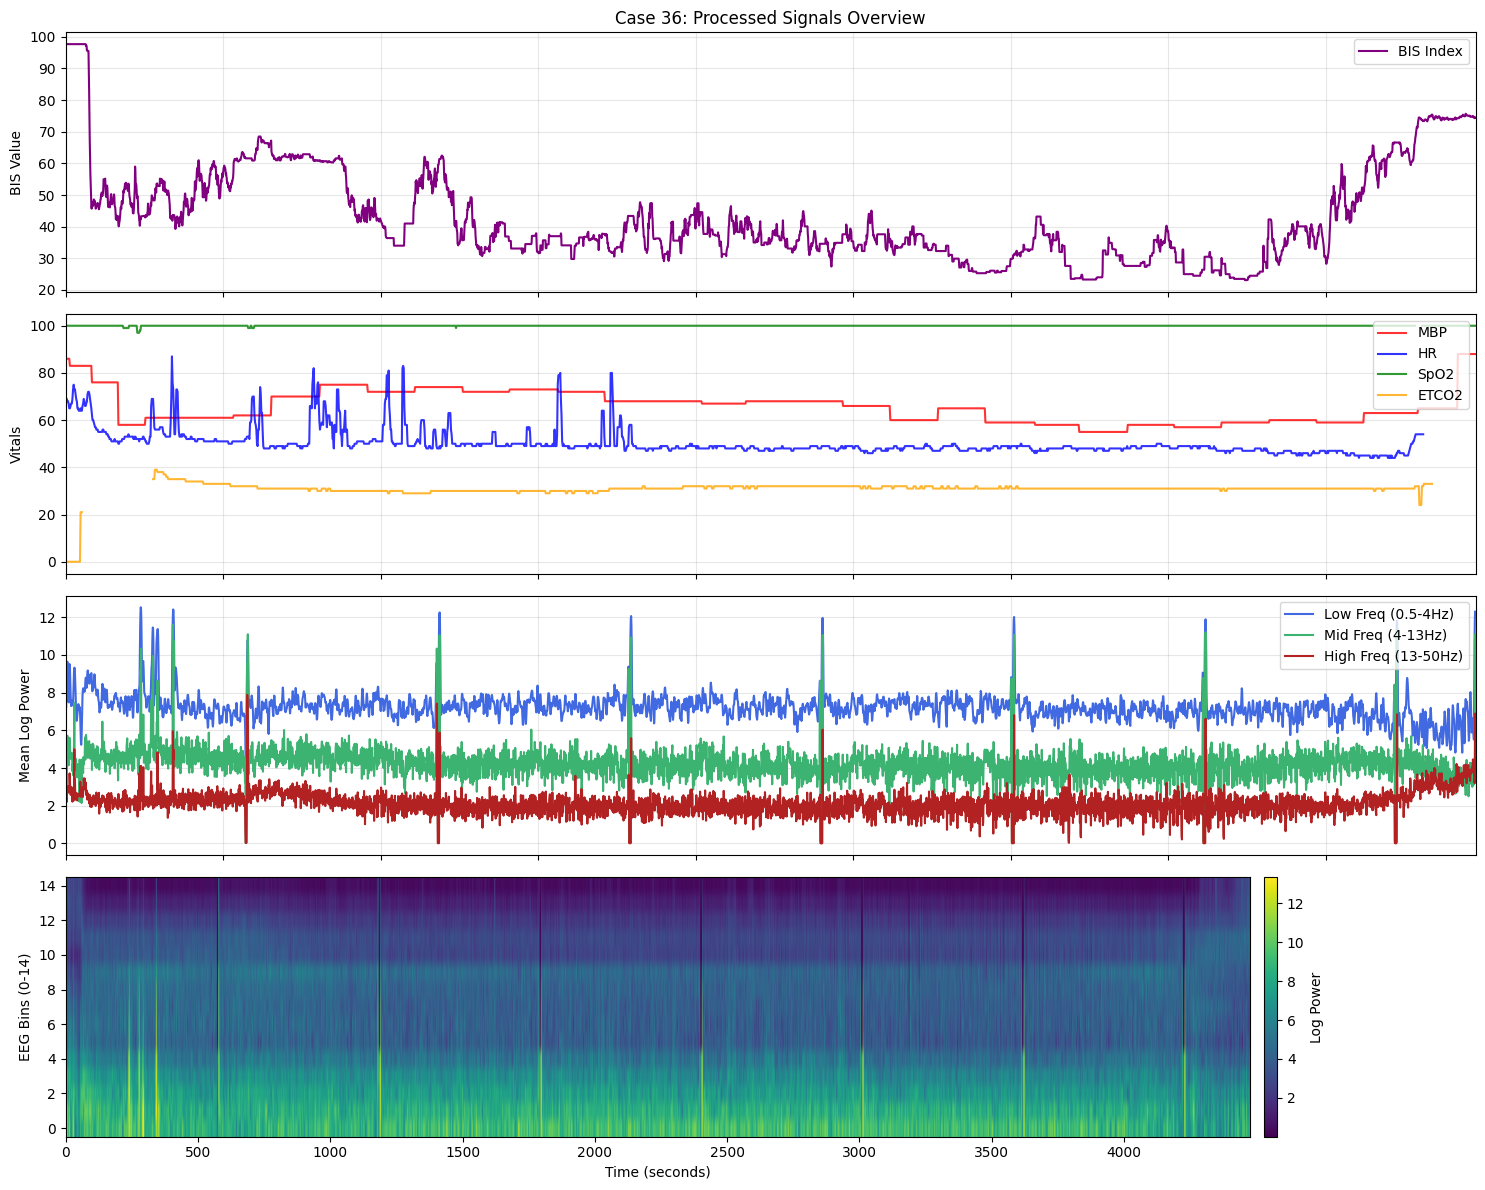

In [11]:
import matplotlib.pyplot as plt

# Convert PyTorch tensors to NumPy arrays for plotting
features_np = features.numpy()
bis_np = bis.numpy()

# The time axis is simply the number of rows (1 row = 1 second)
time_axis = np.arange(features_np.shape[0])

# Create a figure with 4 stacked subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# --- 1. Plot the Target: BIS Index ---
axes[0].plot(time_axis, bis_np, color='purple', label='BIS Index')
axes[0].set_ylabel('BIS Value')
axes[0].set_title(f'Case {caseid}: Processed Signals Overview')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# --- 2. Plot the Vitals (Features 15 to 18) ---
vitals_labels = ['MBP', 'HR', 'SpO2', 'ETCO2']
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    axes[1].plot(time_axis, features_np[:, 15 + i], label=vitals_labels[i], color=colors[i], alpha=0.8)
axes[1].set_ylabel('Vitals')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# --- 3. Plot Aggregated EEG Power Bands ---
# Averaging the 5 bins for each band to show general trends
axes[2].plot(time_axis, np.mean(features_np[:, 0:5], axis=1), label='Low Freq (0.5-4Hz)', color='royalblue')
axes[2].plot(time_axis, np.mean(features_np[:, 5:10], axis=1), label='Mid Freq (4-13Hz)', color='mediumseagreen')
axes[2].plot(time_axis, np.mean(features_np[:, 10:15], axis=1), label='High Freq (13-50Hz)', color='firebrick')
axes[2].set_ylabel('Mean Log Power')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

# --- 4. Plot EEG Features as a "Spectrogram" Heatmap ---
# We transpose (.T) so that Time is on the X-axis and Frequency bins are on the Y-axis
im = axes[3].imshow(features_np[:, 0:15].T, aspect='auto', cmap='viridis', origin='lower')
axes[3].set_ylabel('EEG Bins (0-14)')
axes[3].set_xlabel('Time (seconds)')
fig.colorbar(im, ax=axes[3], label='Log Power', pad=0.01)

plt.tight_layout()
plt.show()

## train/test